In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline


In [6]:
def simulate_gradient_flow(weight: float, num_layers: int = 20):
    x = torch.tensor(1.0)
    w = torch.tensor(weight, requires_grad=True)

    for _ in range(num_layers):
        x = x * w

    x.backward()
    return w.grad.item()

# test gradient vanishing
grad_vanishing = simulate_gradient_flow(weight=0.5, num_layers=20)
print(f"--- gradient vanishing demo (w = 0.5, num layers = 20) ---")
print(f" w.grad = {grad_vanishing:.8f} (close to 0)")

# test gradient exploding
grad_exploding = simulate_gradient_flow(weight=2.0, num_layers=20)
print(f"--- gradient exploding demo (w = 2, num layers = 20) ---")
print(f" w.grad = {grad_exploding:.8f}")

--- gradient vanishing demo (w = 0.5, num layers = 20) ---
 w.grad = 0.00003815 (close to 0)
--- gradient exploding demo (w = 2, num layers = 20) ---
 w.grad = 10485760.00000000


In [7]:
# Simulate gradient flow in MLP
from typing import Any

class DeepMLP(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=10, num_layers=10, activation="sigmoid", init_scale=1.0):
        super().__init__() 
        self.activation_name = activation
        self.layers = nn.ModuleList()

        for i in range(num_layers):
            input_d = input_dim if i == 0 else hidden_dim
            linear = nn.Linear(input_d, hidden_dim)

            #initialize weights
            nn.init.normal_(linear.weight, mean=0.0, std=init_scale)
            nn.init.zeros_(linear.bias)
            self.layers.append(linear)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
            if self.activation_name == "sigmoid":
                x = torch.sigmoid(x)
            elif self.activation_name == "relu":
                x = torch.relu(x)
        return x


In [9]:
def inspect_gradients(model, input_data, target):
    output = model(input_data)
    loss = nn.MSELoss()(output, target)

    model.zero_grad()
    loss.backward()

    #store the gradient norm (mean abs value) for each layer in the model
    layer_grad_means = []
    for layer in model.layers:
        grad_mean = layer.weight.grad.abs().mean().item()
        layer_grad_means.append(grad_mean)
    return layer_grad_means

#create dummy data with batch size 32
x = torch.randn(32, 10)
target = torch.randn(32, 10)


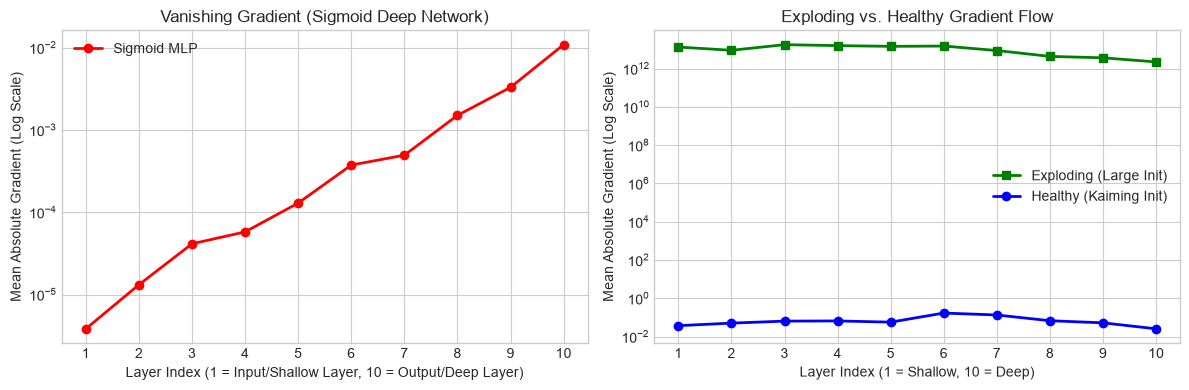

In [10]:

#gradient vanishing with sigmoid when num layers > 10
model_vanishing = DeepMLP(activation="sigmoid", init_scale=1.0)
grads_vanishing = inspect_gradients(model=model_vanishing, input_data=x, target=target)

#gradient exploding with relu when std = 3.0
model_exploding = DeepMLP(activation="relu", init_scale=3.0)
grads_exploding = inspect_gradients(model=model_exploding, input_data=x, target=target)

#normal gradient with relu and Kaiming initialization
model_normal = DeepMLP(activation="relu", init_scale=1.0)
for layer in model_normal.layers:
    if isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight)
grads_normal = inspect_gradients(model=model_normal, input_data=x, target=target)

plt.figure(figsize=(12, 4))

# 1. Draw gradient vanishing
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), grads_vanishing, 'o-r', linewidth=2, label='Sigmoid MLP')
plt.yscale('log') # 使用对数坐标系更容易观察微小梯度
plt.title("Vanishing Gradient (Sigmoid Deep Network)")
plt.xlabel("Layer Index (1 = Input/Shallow Layer, 10 = Output/Deep Layer)")
plt.ylabel("Mean Absolute Gradient (Log Scale)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()

# 2. gradient exploding vs normal
plt.subplot(1, 2, 2)
plt.plot(range(1, 11), grads_exploding, 's-g', linewidth=2, label='Exploding (Large Init)')
plt.plot(range(1, 11), grads_normal, 'o-b', linewidth=2, label='Healthy (Kaiming Init)')
plt.yscale('log')
plt.title("Exploding vs. Healthy Gradient Flow")
plt.xlabel("Layer Index (1 = Shallow, 10 = Deep)")
plt.ylabel("Mean Absolute Gradient (Log Scale)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()